In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("healthexp") 
print(df.head())

   Year        Country  Spending_USD  Life_Expectancy
0  1970        Germany       252.311             70.6
1  1970         France       192.143             72.2
2  1970  Great Britain       123.993             71.9
3  1970          Japan       150.437             72.0
4  1970            USA       326.961             70.9


In [4]:
df['Country'].value_counts()

Country
USA              51
Japan            51
Germany          50
Canada           44
Great Britain    43
France           35
Name: count, dtype: int64

<Axes: xlabel='Country'>

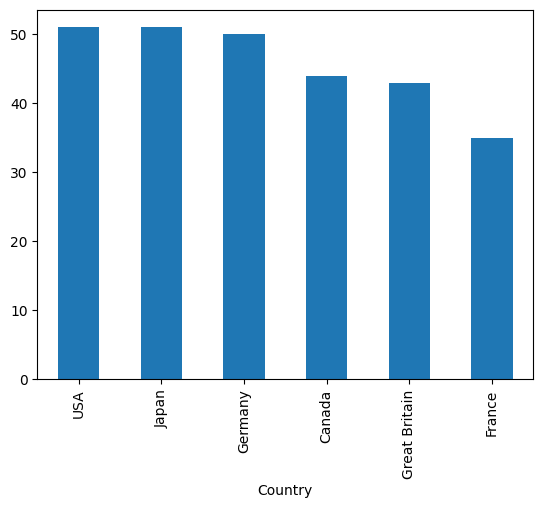

In [6]:
df['Country'].value_counts().plot(kind="bar")

In [5]:
df['Spending_USD'].describe()

count      274.000000
mean      2789.338905
std       2194.939785
min        123.993000
25%       1038.357000
50%       2295.578000
75%       4055.610000
max      11859.179000
Name: Spending_USD, dtype: float64

  La dépense de santé annuelle moyenne, calculée sur l'ensemble des 6 pays et des 51 années d'observations disponibles, s'élève à 2 789,34 USD par habitant 

*****une valeur continue*****

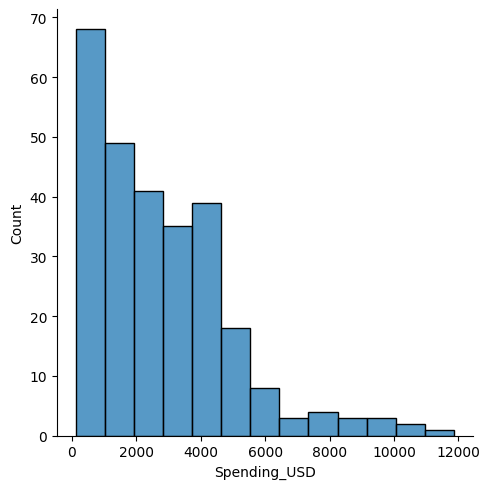

In [7]:
sns.displot(data=df,x='Spending_USD')

<Axes: xlabel='Spending_USD'>

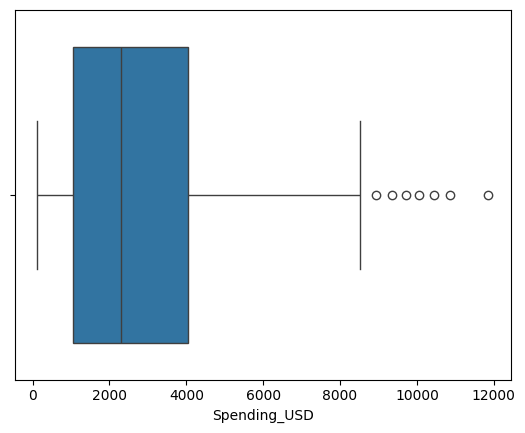

In [8]:
sns.boxplot(data=df,x='Spending_USD')

In [9]:
df['Life_Expectancy'].describe()

count    274.000000
mean      77.909489
std        3.276263
min       70.600000
25%       75.525000
50%       78.100000
75%       80.575000
max       84.700000
Name: Life_Expectancy, dtype: float64

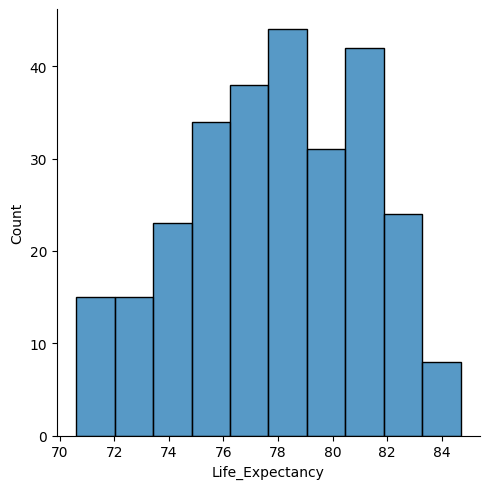

In [10]:
sns.displot(data=df,x='Life_Expectancy')

<Axes: xlabel='Life_Expectancy'>

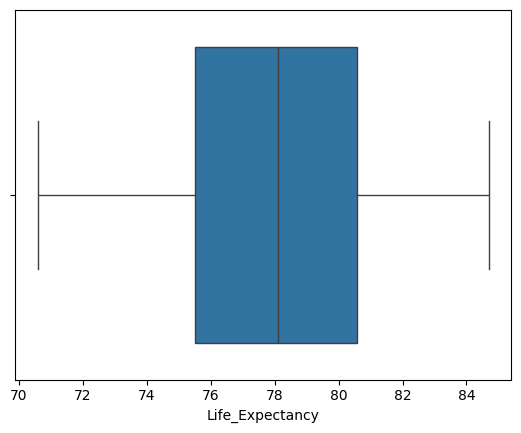

In [12]:
sns.boxplot(data=df,x='Life_Expectancy')

*****Deux valeurs discrete/continue*****

<Axes: xlabel='Year', ylabel='Life_Expectancy'>

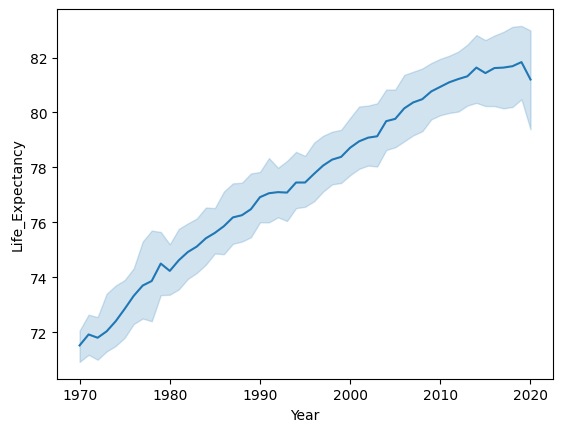

In [13]:
sns.lineplot(x='Year',y='Life_Expectancy',data=df)

In [20]:
df.groupby('Year')['Life_Expectancy'].mean()

Year
1970    71.520000
1971    71.920000
1972    71.800000
1973    72.033333
1974    72.400000
1975    72.850000
1976    73.325000
1977    73.700000
1978    73.866667
1979    74.500000
1980    74.233333
1981    74.620000
1982    74.920000
1983    75.120000
1984    75.420000
1985    75.616667
1986    75.860000
1987    76.180000
1988    76.260000
1989    76.480000
1990    76.916667
1991    77.060000
1992    77.100000
1993    77.083333
1994    77.450000
1995    77.450000
1996    77.766667
1997    78.066667
1998    78.283333
1999    78.383333
2000    78.716667
2001    78.950000
2002    79.083333
2003    79.133333
2004    79.683333
2005    79.766667
2006    80.150000
2007    80.366667
2008    80.483333
2009    80.766667
2010    80.933333
2011    81.100000
2012    81.216667
2013    81.316667
2014    81.633333
2015    81.433333
2016    81.616667
2017    81.633333
2018    81.683333
2019    81.833333
2020    81.200000
Name: Life_Expectancy, dtype: float64

<Axes: xlabel='Year'>

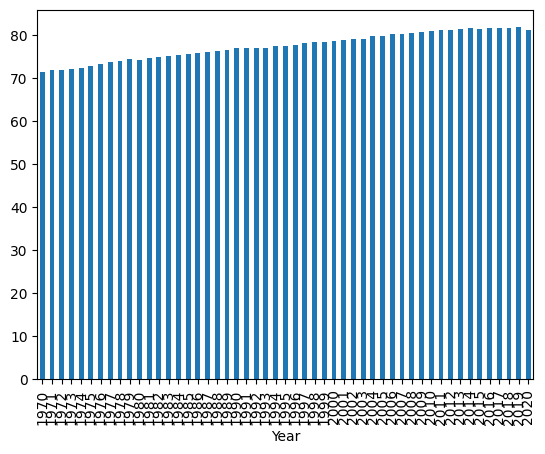

In [21]:
df.groupby('Year')['Life_Expectancy'].mean().plot(kind='bar')

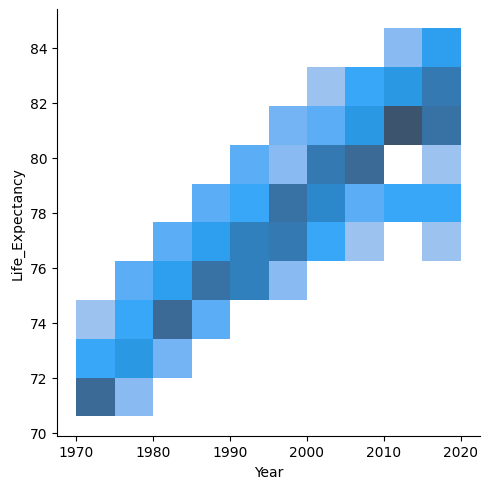

In [23]:
sns.displot(data=df,x='Year',y='Life_Expectancy')

<Axes: xlabel='Year', ylabel='Life_Expectancy'>

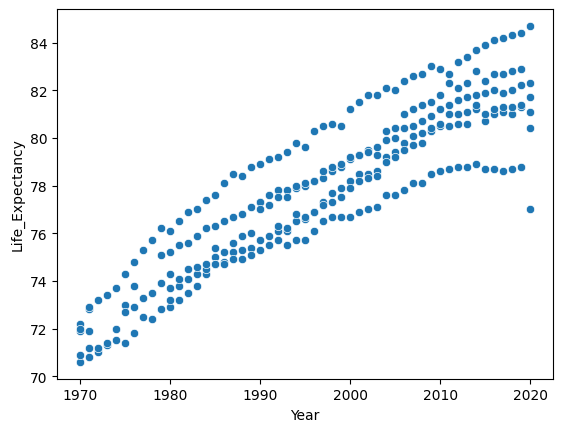

In [25]:
sns.scatterplot(data=df,x='Year',y='Life_Expectancy')

<Axes: xlabel='Year', ylabel='Life_Expectancy'>

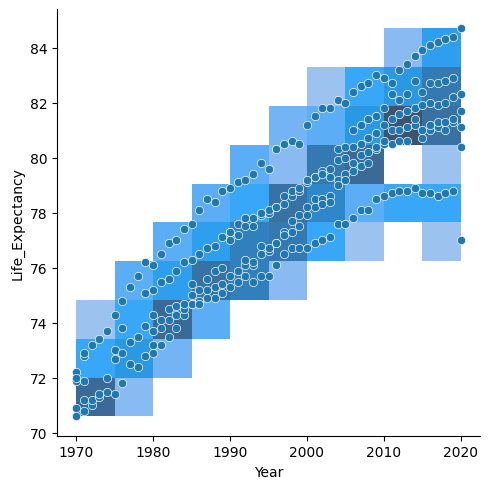

In [26]:
sns.displot(data=df,x='Year',y='Life_Expectancy')
sns.scatterplot(data=df,x='Year',y='Life_Expectancy')

<Axes: xlabel='Year', ylabel='Life_Expectancy'>

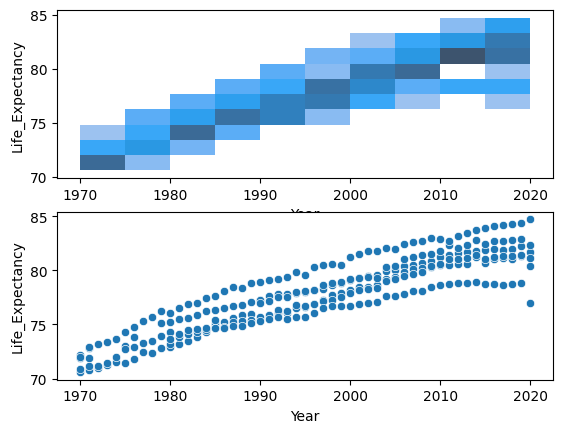

In [30]:


# 2. Le graphique du HAUT (ligne 2, colonne 1, position 1)
plt.subplot(2, 1, 1)
sns.histplot(data=df, x='Year', y='Life_Expectancy')

# 3. Le graphique du BAS (ligne 2, colonne 1, position 2)
plt.subplot(2, 1, 2)
sns.scatterplot(data=df, x='Year', y='Life_Expectancy')



******deux valeurs descrete et continue ******
Country VS Spendine_USD


In [16]:
df.groupby('Spending_USD')['Year'].mean()

Spending_USD
123.993      1970.0
134.172      1971.0
150.437      1970.0
163.854      1971.0
185.390      1972.0
              ...  
9717.649     2016.0
10046.472    2017.0
10451.386    2018.0
10855.517    2019.0
11859.179    2020.0
Name: Year, Length: 274, dtype: float64

<Axes: xlabel='Country'>

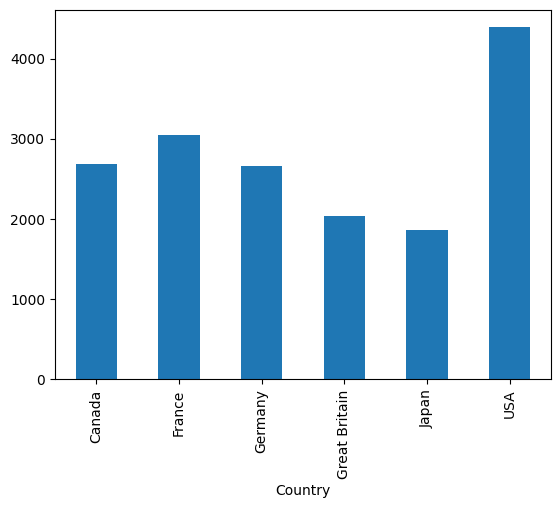

In [19]:
df.groupby('Country')['Spending_USD'].mean().plot(kind='bar')

<Axes: xlabel='Country', ylabel='Spending_USD'>

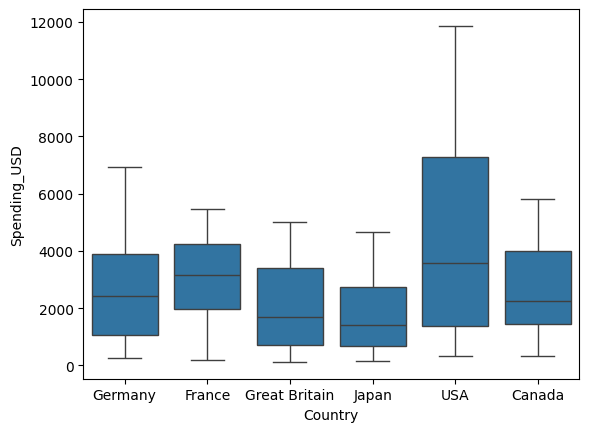

In [22]:
sns.boxplot(data=df,x='Country',y='Spending_USD')

<Axes: xlabel='Country', ylabel='Life_Expectancy'>

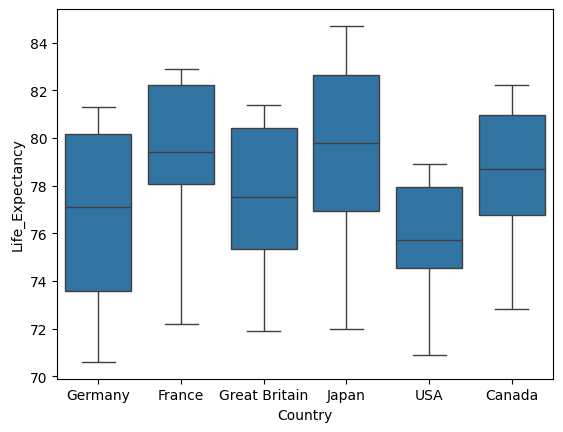

In [31]:
sns.boxplot(data=df,x='Country',y='Life_Expectancy')

<Axes: xlabel='Country'>

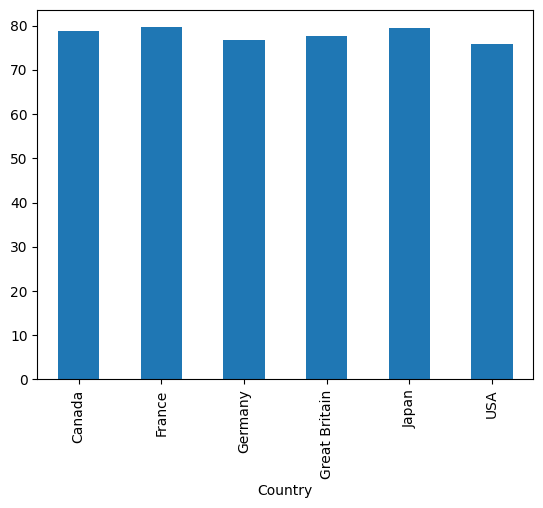

In [33]:
df.groupby('Country')['Life_Expectancy'].mean().plot(kind='bar')

Observez la relation entre la durée de vie et les dépenses dans la santé, aux États-Unis, de 2000 à 2020

<Axes: xlabel='Spending_USD', ylabel='Life_Expectancy'>

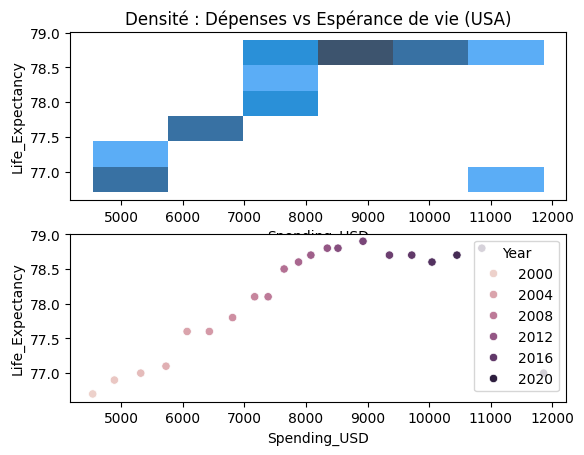

In [39]:
usa_df = df[(df['Country'] == 'USA') & (df['Year'] >= 2000) & (df['Year'] <= 2020)]

plt.subplot(2, 1, 1)
sns.histplot(data=usa_df, x='Spending_USD', y='Life_Expectancy')
plt.title("Densité : Dépenses vs Espérance de vie (USA)")


plt.subplot(2, 1, 2)
sns.scatterplot(data=usa_df, x='Spending_USD', y='Life_Expectancy',hue='Year')




Il y a une valeur abérante tant tout cela. Laquelle? Pourquoi? 

La valeur abérante de l'annee 2020(COVID19), on voit une chute remarquable 

In [ ]:
from scipy.stats import pearsonr
df_us = df[df['Country'] == 'USA']
dfus_20202000= df_us[(df_us['Year'] <= 2020) & (df_us['Year'] >= 2000)]
pearsonr(dfus_20202000["Life_Expectancy"],dfus_20202000["Spending_USD"])